# Sensitivity to initial residual concentration

In [ ]:
from functools import partial
import numpy as np
from lucifex.sim import parallel_run, as_grid_simulation
from lucifex.plt import (
    plot_colormap, plot_line, set_ipynb_variable, 
    save_figure, get_ipynb_file_name
)
from lucifex.utils.array_utils import as_index
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE

NX = 60
NY = 60
CELL_TYPE = 'quadrilateral'
COURANT_ADV = 0.75
COURANT_DIFF = 0.75
COURANT_REAC = 0.1
C_SEED = (1234, 5678)
cr_opts = (0.0, 1.0)
Da_opts = tuple(i * SYSTEM_A_REFERENCE['Da'] for i in (1.0, 0.1))

n_proc = set_ipynb_variable('N_PROC', 3)
n_stop = set_ipynb_variable('N_STOP', 500)
dt_init = 1e-6
n_init = 10

STORE = 1
create_sim = dns_system_a(store_delta=STORE)

simulations = parallel_run(
    create_sim, n_proc, n_stop, 
    dt_init=dt_init, n_init=n_init,
    serialize=partial(as_grid_simulation,  slc_func='::5', include=('c', 'uMinMax', 'uRMS', 'f')),
    link=False,
)(
    Nx=NX,
    Ny=NY,
    cell=CELL_TYPE,
    scaling='advective',
    **{k: v for k, v in SYSTEM_A_REFERENCE.items() if not k in ('Da', 'cr')},
    courant_adv=COURANT_ADV,
    courant_diff=COURANT_DIFF,
    courant_reac=COURANT_REAC,
    c_stabilization=None,
    c_limits=True,
    diagnostic=True,
)(
    Da=Da_opts,
    cr=cr_opts,
)

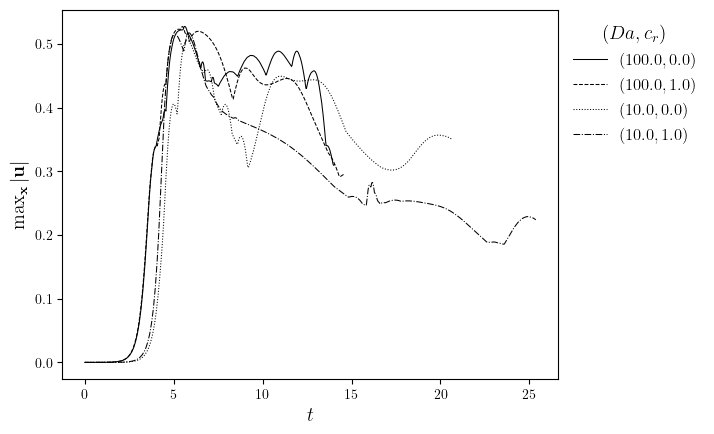

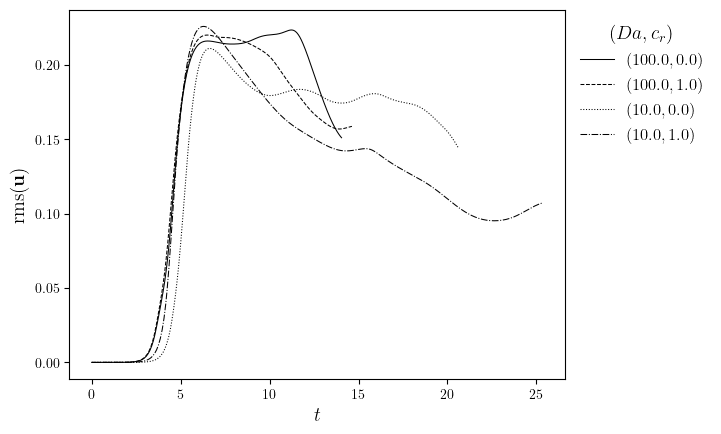

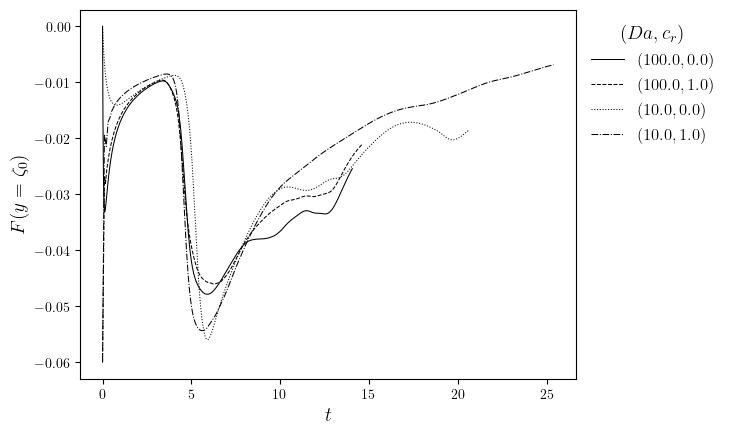

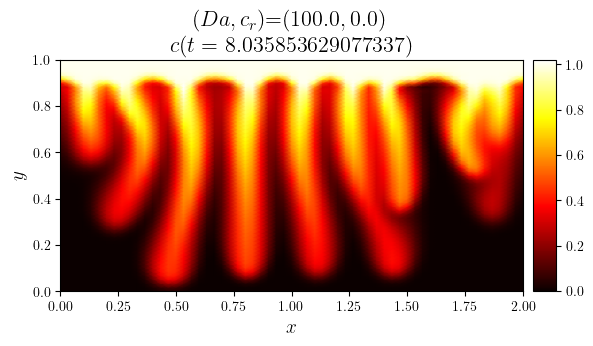

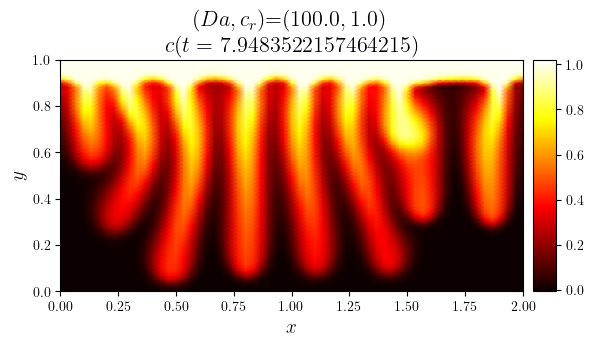

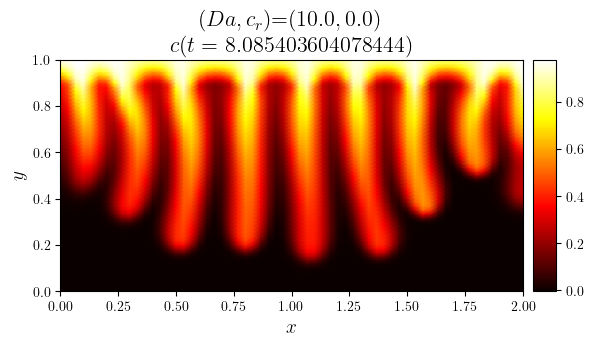

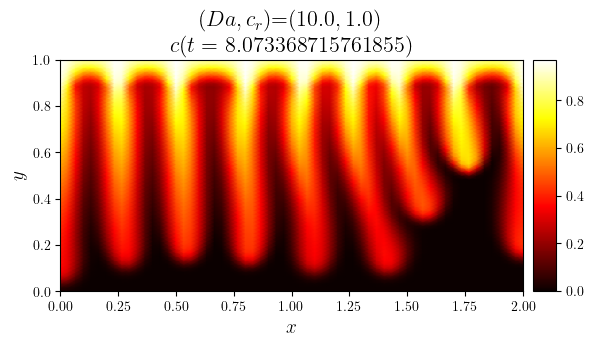

: 

In [ ]:
DIR_FIGS = f'./figures/{get_ipynb_file_name()}'

uMax_lines, uRMS_lines, f_lines, labels = [], [], [], []
legend_title = f'$(Da, c_r)$'

cmap_t_target = 8.0
cmap_funcs, cmap_titles, cmap_names = [], [], []

for (Da, cr), sim in simulations.items():
    label = f'$({Da}, {cr})$'
    labels.append(label)
    sim = simulations[(Da, cr)]
    f = sim['f']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    f_lines.append((fZeta0.time_series, [np.sum(i) for i in fZeta0.value_series]))
    uMinMax = sim['uMinMax']
    uMax = uMinMax.sub(1)
    uMax_lines.append((uMax.time_series, uMax.value_series))
    uRMS = sim['uRMS']
    uRMS_lines.append((uRMS.time_series, uRMS.value_series))
    c = sim['c']
    time_index = as_index(c.time_series, cmap_t_target)
    t = c.time_series[time_index]
    cmap_funcs.append(c.series[time_index])
    cmap_titles.append(f'{legend_title}$ = ${label}\n$c(t={t})$')
    cmap_names.append(f'c(x,y,t={t:.4f})__Da={Da}|cr={cr}')

line_kws = dict(
    cyc='black',
    x_label='$t$',
    legend_labels=labels,
    legend_title=legend_title,
)  

fig, ax = plot_line(
    uMax_lines,
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
    **line_kws,
)
save_figure('uMax(t)', DIR_FIGS, prefix=False)(fig)

fig, ax = plot_line(
    uRMS_lines,
    y_label='$\mathrm{rms}(\mathbf{u})$',
    **line_kws,
)
save_figure('uRMS(t)', DIR_FIGS, prefix=False)(fig)

fig, ax = plot_line(
    f_lines,
    y_label='$F(y=\zeta_0)$',
    **line_kws,
)

for func, title, name in zip(cmap_funcs, cmap_titles, cmap_names): 
    fig, ax = plot_colormap(func, title=title)
    save_figure(name, DIR_FIGS, prefix=False)(fig)